# Construction Cost Risk Forecasting

contractors in india bid on projects based on current material prices. but projects take 2-4 years to complete. by the time execution happens, cement, steel and bitumen prices have moved — sometimes a lot.

this notebook tries to forecast those price movements using india's wholesale price index (wpi) data. the idea is simple: if we can get a reasonable estimate of where prices are headed, contractors can build that into their bids instead of guessing.

what we are working with:
- wpi data from the office of the economic adviser (oea), india — base year 2011-12 = 100
- macro data from rbi: repo rate, exchange rate, iip, cpi, m3
- crude oil prices from fred (brent and wti)

target variable: ordinary portland cement (opc) wpi — one month ahead

date range: april 2012 to january 2026

## 1. imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 500)

## 2. load raw data

three sources: wpi from oea excel, macro indicators from rbi excel, crude oil from fred api.

all three get merged on the date index at the end of this section.

In [2]:
# --- WPI data from OEA ---
# the excel from oea has commodities as rows and months as columns
# we transpose it so that months become rows which is what we need

wpi_file_path = r"E:\consultancy model\data\raw\wpi\wpi_monthly_data.xlsx"
wpi = pd.read_excel(wpi_file_path)

wpi.drop(columns=['COMM_WT', 'COMM_CODE'], inplace=True)
wpi = wpi.set_index('COMM_NAME').T
wpi.index.name = 'date'
wpi.columns.name = None

# only keeping the commodities relevant to construction cost
keep_names = [
    "Ordinary Portland cement",
    "Bitumen",
    "a. Inputs into steel making",
    'Electricity', 'LPG', 'Natural Gas', 'Petrol'
]

wpi.columns = wpi.columns.astype(str).str.strip().str.lower().str.replace(r' ', '_', regex=True)
keep_names = [name.strip().lower().replace(' ', '_') for name in keep_names]
wpi = wpi[keep_names]
wpi = wpi.apply(pd.to_numeric, errors='coerce')

wpi.index = pd.to_datetime(wpi.index.str.replace('INDX', ''), format='%m%Y').to_period('M')
wpi = wpi[wpi.index <= '2026-01']

print(wpi.shape)
wpi.head()

(166, 7)


,ordinary_portland_cement,bitumen,a._inputs_into_steel_making,electricity,lpg,natural_gas,petrol
date,,,,,,,
2012-04,110.6,102.0,115.5,97.4,111.1,108.0,106.2
2012-05,109.1,103.9,114.9,100.8,106.3,113.2,108.6
2012-06,109.2,106.1,113.6,102.5,101.7,116.3,112.1
2012-07,111.3,106.1,109.2,101.8,97.4,115.2,105.7
2012-08,111.2,105.9,107.7,98.5,91.9,115.4,110.6


In [3]:
# --- RBI macro data ---

file_path = r"E:\consultancy model\data\raw\rbi\rbi_table.xlsx"
rbi = pd.read_excel(file_path, header=5, index_col="date")

rbi.index = pd.to_datetime(rbi.index).to_period('M')
rbi = rbi.drop(rbi[rbi.index == '1970-01'].index)  # bad row oea sometimes includes
rbi = rbi[rbi.index >= '2012-04']

columns_to_keep = [
    '1.2   Index of Industrial Production',
    '2.2.2 Broad Money (M3)',
    '4.1 interest rates(%)   Policy Repo Rate',
    '5.1 5 RBI Reference Rate and Forward Premia,   INR-US$ Spot Rate (Rs. Per Foreign Currency)',
    '6.1   All India Consumer Price Index'
]

for col in rbi.columns.tolist():
    if col not in columns_to_keep:
        rbi = rbi.drop(columns=col)

rbi.columns = rbi.columns.astype(str).str.strip().str.lower().str.replace(r' ', '_', regex=True)
rbi = rbi.apply(pd.to_numeric, errors='coerce')

print(rbi.shape)
rbi.head()

(166, 5)


,1.2___index_of_industrial_production,2.2.2_broad_money_(m3),4.1_interest_rates(%)___policy_repo_rate,"5.1_5_rbi_reference_rate_and_forward_premia,___inr-us$_spot_rate_(rs._per_foreign_currency)",6.1___all_india_consumer_price_index
date,,,,,
2026-01,4.826733,12.027650,5.25,91.8983,2.734337
2025-12,7.784810,12.111155,5.25,89.8296,1.166181
2025-11,7.157326,9.877754,5.50,89.4557,0.492754
2025-10,0.532269,10.301629,5.50,88.7241,0.254065
2025-09,4.628999,9.231437,5.50,88.7234,1.441813


In [4]:
# --- Crude oil from FRED ---
fred_client = Fred(api_key='c66054dae24e0f042f2c648dcd97fe9c')

brent = fred_client.get_series('DCOILBRENTEU', observation_start='2012-04-01', observation_end='2026-01-31')
wti = fred_client.get_series('DCOILWTICO', observation_start='2012-04-01', observation_end='2026-01-31')

crude_df = pd.DataFrame({'brent_crude_usd': brent, 'wti_crude_usd': wti})
crude_df.index = pd.to_datetime(crude_df.index).to_period('M')
crude_df.index.name = 'date'

crude_df = crude_df.groupby(crude_df.index).mean()

print(crude_df.shape)
crude_df.head()

(166, 2)


,brent_crude_usd,wti_crude_usd
date,,
2012-04,119.421667,103.321000
2012-05,110.339524,94.654545
2012-06,95.155714,82.303333
2012-07,102.618571,87.895238
2012-08,113.356087,94.131304


In [5]:
# --- merge all three sources ---
master = pd.concat([wpi, rbi, crude_df], axis=1)
print(master.shape)
print(master.isnull().sum())
master.head()

(166, 14)
ordinary_portland_cement                                                                       0
bitumen                                                                                        0
a._inputs_into_steel_making                                                                    0
electricity                                                                                    0
lpg                                                                                            0
natural_gas                                                                                    0
petrol                                                                                         0
1.2___index_of_industrial_production                                                           2
2.2.2_broad_money_(m3)                                                                         0
4.1_interest_rates(%)___policy_repo_rate                                                       0
5.1_5_rbi_reference_

,ordinary_portland_cement,bitumen,a._inputs_into_steel_making,electricity,lpg,natural_gas,petrol,1.2___index_of_industrial_production,2.2.2_broad_money_(m3),4.1_interest_rates(%)___policy_repo_rate,"5.1_5_rbi_reference_rate_and_forward_premia,___inr-us$_spot_rate_(rs._per_foreign_currency)",6.1___all_india_consumer_price_index,brent_crude_usd,wti_crude_usd
date,,,,,,,,,,,,,,
2012-04,110.6,102.0,115.5,97.4,111.1,108.0,106.2,-1.263538,13.269282,8.0,52.5193,10.26,119.421667,103.321000
2012-05,109.1,103.9,114.9,100.8,106.3,113.2,108.6,2.466907,13.845944,8.0,56.4225,10.36,110.339524,94.654545
2012-06,109.2,106.1,113.6,102.5,101.7,116.3,112.1,-1.983664,15.823262,8.0,56.3090,9.93,95.155714,82.303333
2012-07,111.3,106.1,109.2,101.8,97.4,115.2,105.7,-0.059809,13.963623,8.0,55.8070,9.86,102.618571,87.895238
2012-08,111.2,105.9,107.7,98.5,91.9,115.4,110.6,2.044610,14.093591,8.0,55.7215,10.03,113.356087,94.131304


## 3. look at the data

before doing anything with a model it helps to just look at what the data actually looks like.

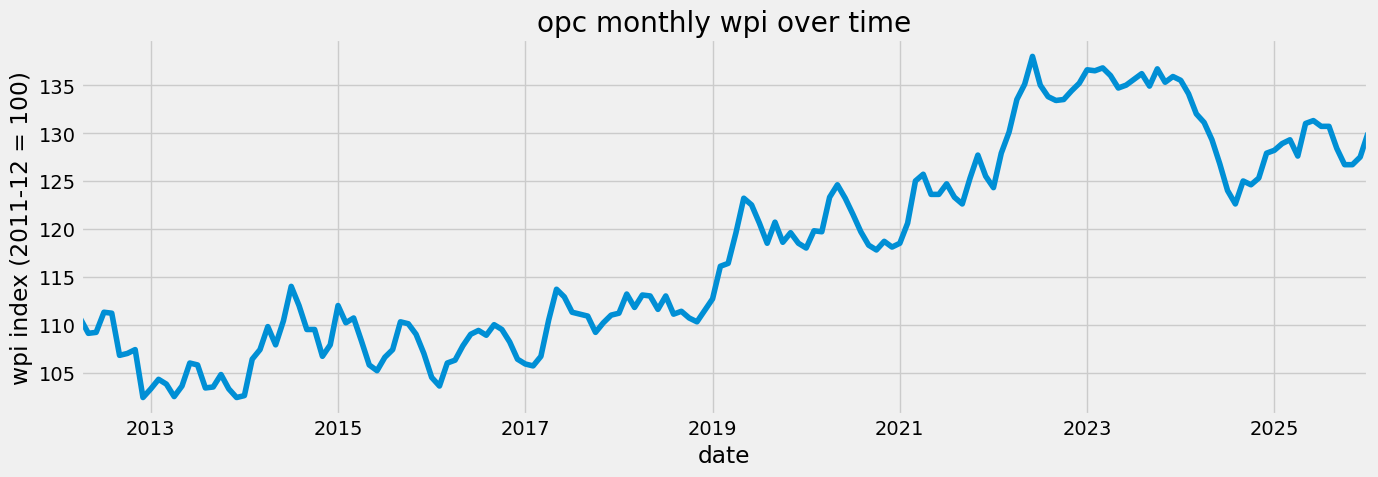

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
master['ordinary_portland_cement'].plot(ax=ax)
ax.set_title('opc monthly wpi over time')
ax.set_ylabel('wpi index (2011-12 = 100)')
ax.set_xlabel('date')
plt.tight_layout()
plt.show()

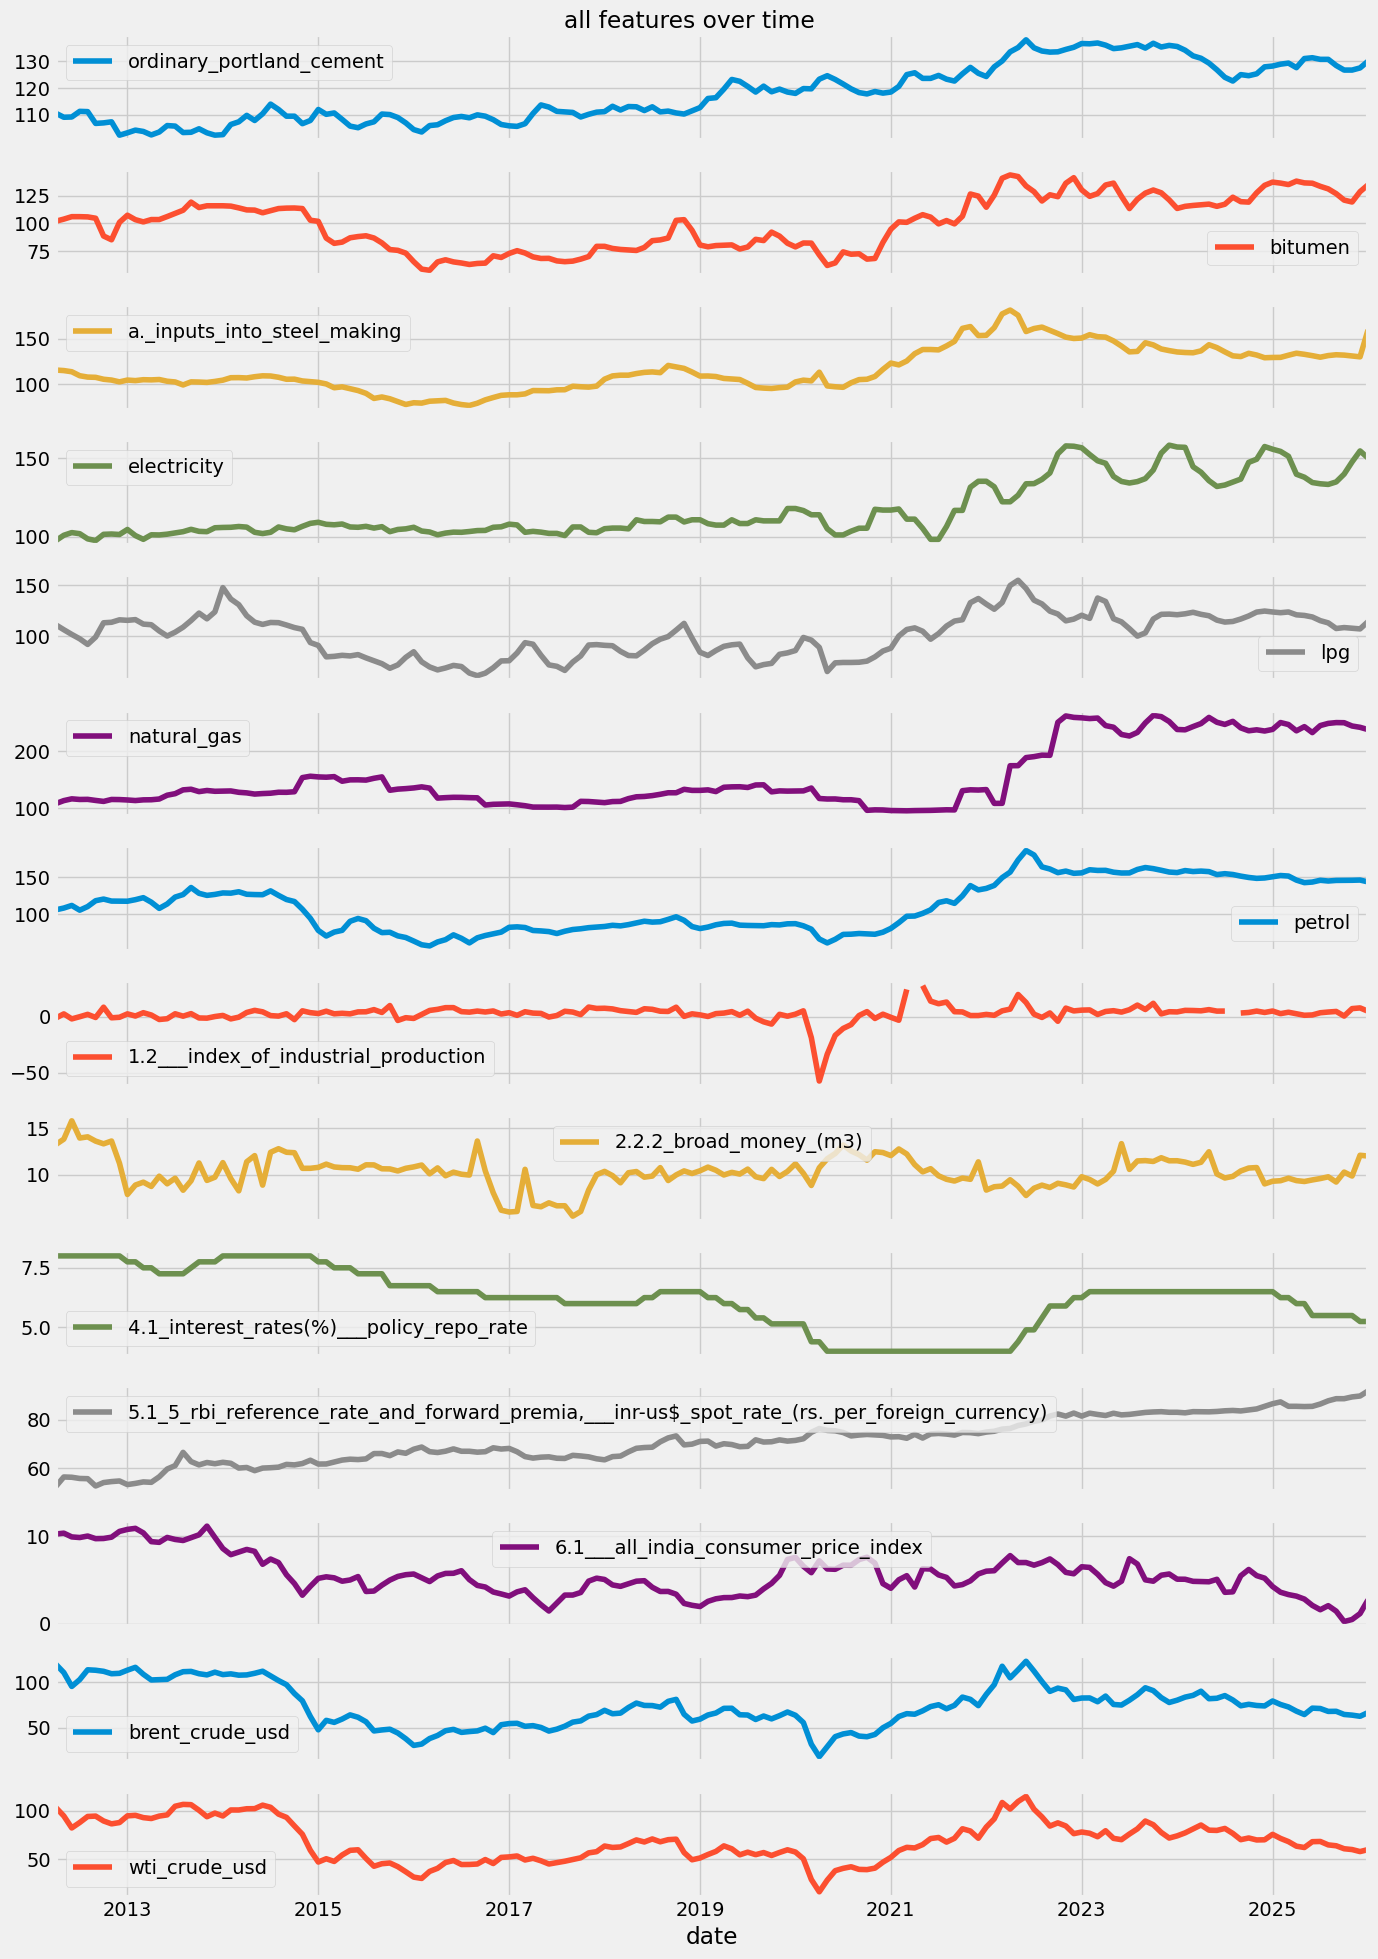

In [7]:
# plotting all features to see how they move
master.plot(subplots=True, figsize=(14, 20), title='all features over time')
plt.tight_layout()
plt.show()

## 4. feature engineering

xgboost does not understand time — it just sees numbers in columns. so we have to manually create features that carry time information.

what we are creating:
- **target**: opc wpi shifted by -1 (next month's value — what we want to predict)
- **lag 3 of opc**: opc value from 3 months ago — gives the model a quarterly memory
- **outlier flag**: binary column marking months where opc was unusually high — handles the 2022 spike

In [8]:
df = master.copy()

# target: next month's opc value
# shifting by -1 moves each row's value one position up
# so row for jan gets feb's value, row for feb gets march's value, etc.
df['target'] = df['ordinary_portland_cement'].shift(-1)

# lag 3: opc value from 3 months ago
# gives the model a sense of where prices were heading into this month
df['opc_lag3'] = df['ordinary_portland_cement'].shift(3)

# outlier flag: 1 if this month's opc is more than 2 std devs above the 12-month rolling mean
# this marks the 2022 spike so the model knows those months were unusual
rolling_mean = df['ordinary_portland_cement'].rolling(12).mean()
rolling_std = df['ordinary_portland_cement'].rolling(12).std()
df['opc_outlier_flag'] = ((df['ordinary_portland_cement'] - rolling_mean) > 2 * rolling_std).astype(int)

# drop rows with nulls introduced by the shifts and rolling window
df = df.dropna().reset_index(drop=True)

print(df.shape)
print(f"outlier months flagged: {df['opc_outlier_flag'].sum()}")

(160, 17)
outlier months flagged: 10


## 5. train test split

for time series data you cannot split randomly — the model would see future data during training which makes evaluation meaningless.

rule: everything before a cutoff date goes to train, everything after goes to test.

In [9]:
feature_cols = [col for col in df.columns if col != 'target']

X = df[feature_cols]
y = df['target']

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (128, 16), test: (32, 16)


## 6. baseline model

before tuning anything, we train a model with default parameters to know where we are starting from.

In [10]:
baseline_model = XGBRegressor(random_state=42)
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

print(f"baseline MAE : {baseline_mae:.3f}")
print(f"baseline RMSE: {baseline_rmse:.3f}")

baseline MAE : 1.914
baseline RMSE: 2.462


## 7. walk forward validation

testing on one chunk of data can be misleading — those months might be unusually easy or hard to predict.

walk forward validation splits the training data into multiple folds where each fold trains on more data and tests on the next unseen chunk. this gives a more reliable picture of how the model actually performs.

In [11]:
tscv = TimeSeriesSplit(n_splits=3)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    m = XGBRegressor(random_state=42)
    m.fit(X_tr, y_tr)
    preds = m.predict(X_val)

    fold_mae = mean_absolute_error(y_val, preds)
    cv_scores.append(fold_mae)
    print(f"fold {fold+1} MAE: {fold_mae:.3f}")

print(f"\naverage CV MAE: {np.mean(cv_scores):.3f}")

fold 1 MAE: 2.015
fold 2 MAE: 6.885
fold 3 MAE: 7.533

average CV MAE: 5.478


## 8. hyperparameter tuning

instead of guessing parameters, we try a grid of values and let the model tell us what works best.

In [12]:
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

grid_search.fit(X_train, y_train)

print(f"best params: {grid_search.best_params_}")
print(f"best CV MAE: {abs(grid_search.best_score_):.3f}")

best params: {'learning_rate': 0.3, 'n_estimators': 100}
best CV MAE: 5.478


## 9. final model

retrain with the best parameters and compare to baseline.

In [13]:
best_params = grid_search.best_params_

final_model = XGBRegressor(**best_params, random_state=42)
final_model.fit(X_train, y_train)

final_preds = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))

print(f"baseline  — MAE: {baseline_mae:.3f}  RMSE: {baseline_rmse:.3f}")
print(f"tuned     — MAE: {final_mae:.3f}  RMSE: {final_rmse:.3f}")

baseline  — MAE: 1.914  RMSE: 2.462
tuned     — MAE: 1.914  RMSE: 2.462


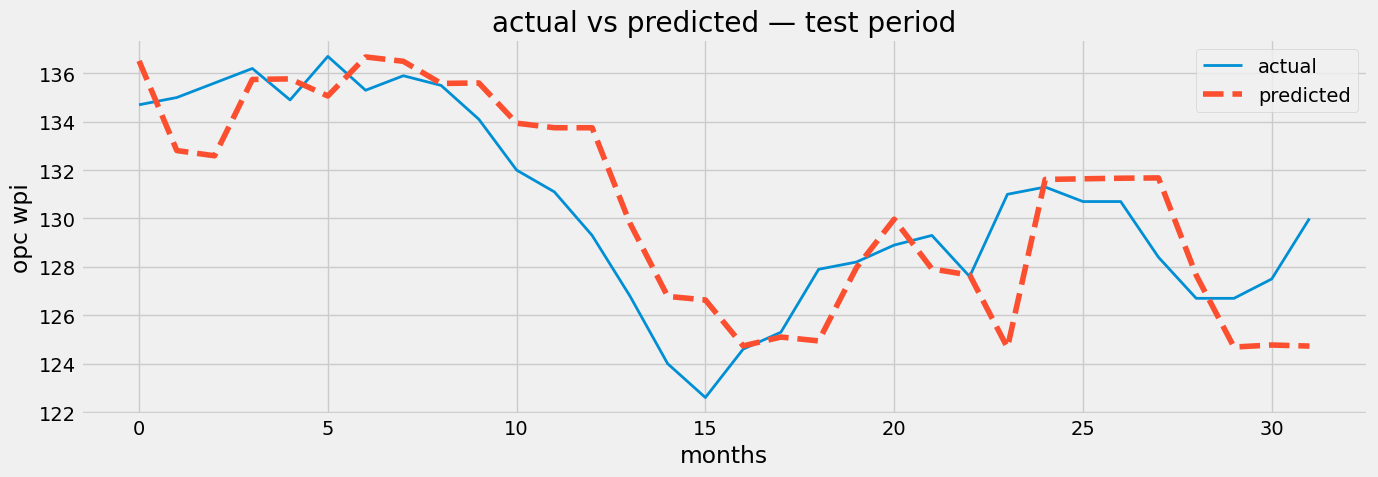

In [14]:
# actual vs predicted on the test period
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.values, label='actual', linewidth=2)
ax.plot(final_preds, label='predicted', linestyle='--')
ax.set_title('actual vs predicted — test period')
ax.set_ylabel('opc wpi')
ax.set_xlabel('months')
ax.legend()
plt.tight_layout()
plt.show()

## 10. what is the model actually using

feature importance tells us which variables the model relied on most. useful for understanding whether the model is learning sensible relationships.

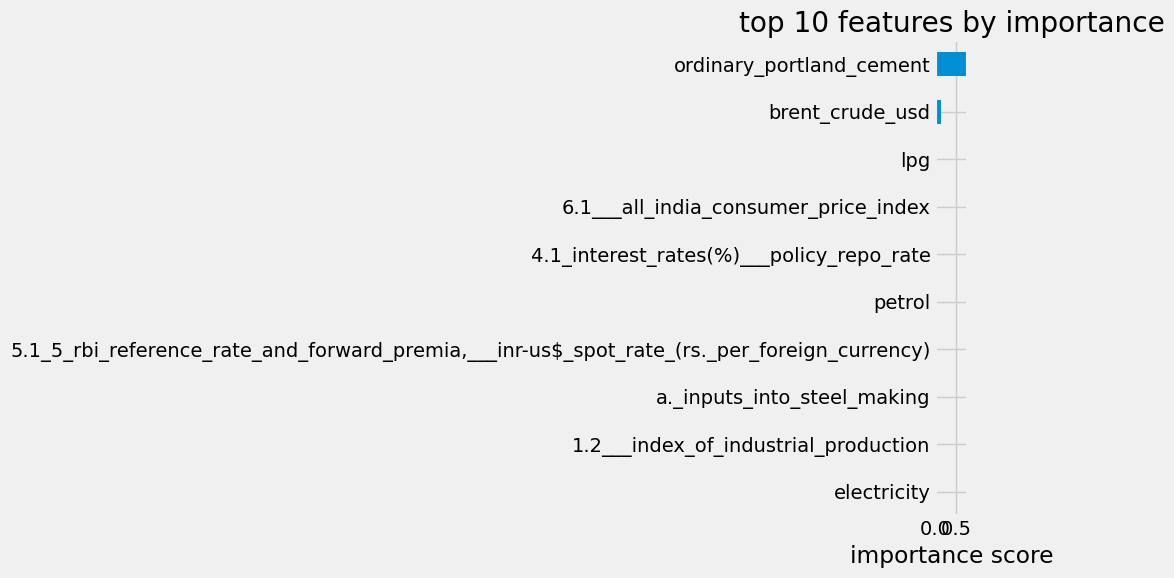

ordinary_portland_cement                                                                       0.759648
brent_crude_usd                                                                                0.150116
lpg                                                                                            0.017322
6.1___all_india_consumer_price_index                                                           0.014266
4.1_interest_rates(%)___policy_repo_rate                                                       0.014147
petrol                                                                                         0.011533
5.1_5_rbi_reference_rate_and_forward_premia,___inr-us$_spot_rate_(rs._per_foreign_currency)    0.007051
a._inputs_into_steel_making                                                                    0.006551
1.2___index_of_industrial_production                                                           0.005312
electricity                                                     

In [15]:
importance = pd.Series(final_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importance.head(10).plot(kind='barh', ax=ax)
ax.set_title('top 10 features by importance')
ax.set_xlabel('importance score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.head(10))

## 11. predict next month

the last row of the dataset represents january 2026. feeding it to the model gives us the predicted opc wpi for february 2026.

In [16]:
last_row = X.tail(1)
feb_prediction = final_model.predict(last_row)

print(f"predicted OPC WPI for february 2026: {feb_prediction[0]:.2f}")
print(f"model test MAE: ±{final_mae:.2f} index points")
print(f"so the likely range is: {feb_prediction[0] - final_mae:.2f} to {feb_prediction[0] + final_mae:.2f}")

predicted OPC WPI for february 2026: 124.73
model test MAE: ±1.91 index points
so the likely range is: 122.81 to 126.64


## 12. what this means for cost overrun estimation

the prediction above is for one month ahead. for a contractor bidding on a 2-4 year project, the more useful number is the expected escalation over the project duration.

a simple way to estimate that: take the current opc wpi, apply the historical average annual growth rate, and build a range around it using the model's MAE as the uncertainty band.

this is not a perfect forecast. it is a defensible, data-driven estimate — which is more than most cost escalation approaches currently used in indian infrastructure contracting.

In [17]:
# escalation table: what does historical data suggest for 1, 2, 3, 4 year horizons
current_opc = df['ordinary_portland_cement'].iloc[-1]

# annual growth rate from the full dataset
annual_growth = df['ordinary_portland_cement'].pct_change(12).mean()

print(f"current OPC WPI (jan 2026): {current_opc:.2f}")
print(f"historical avg annual growth: {annual_growth*100:.2f}%")
print()
print(f"{'horizon':<15} {'base estimate':<20} {'low estimate':<20} {'high estimate'}")
print("-" * 65)

for years in [1, 2, 3, 4]:
    base = current_opc * ((1 + annual_growth) ** years)
    low = base * 0.93   # ~7% downside buffer
    high = base * 1.07  # ~7% upside buffer
    escalation_pct = ((base - current_opc) / current_opc) * 100
    print(f"{str(years) + ' year':<15} {base:.1f} (+{escalation_pct:.1f}%){'':>5} {low:.1f}{'':>10} {high:.1f}")

current OPC WPI (jan 2026): 127.50
historical avg annual growth: 1.71%

horizon         base estimate        low estimate         high estimate
-----------------------------------------------------------------
1 year          129.7 (+1.7%)      120.6           138.8
2 year          131.9 (+3.5%)      122.7           141.1
3 year          134.2 (+5.2%)      124.8           143.5
4 year          136.5 (+7.0%)      126.9           146.0
